In [1]:
# pip install pytesseract pillow
import pytesseract
from PIL import Image

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Program Files\Tesseract-OCR\tesseract.exe"
)

In [2]:
import cv2
import matplotlib.pyplot as plt

def display_img(result_img):
    # Convert ONCE for matplotlib and show
    result_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(result_rgb)
    plt.axis("on")
    plt.show()

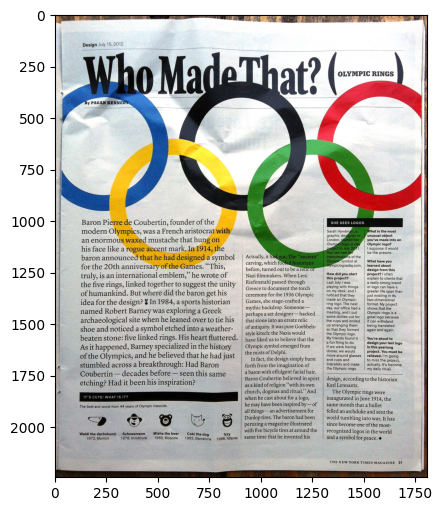

In [19]:
olympics = cv2.imread("docs/olympic_paper.jpg")
display_img(olympics)

(1, 5, 3)


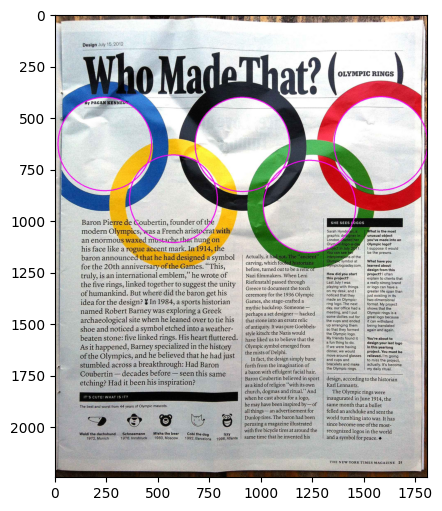

In [40]:
import cv2
import numpy as np

olympics = cv2.imread("docs/olympic_paper.jpg")
#display_img(olympics)

gray_img = cv2.cvtColor(olympics, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, 5)
cimg = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)

circles = cv2.HoughCircles(
    img,
    cv2.HOUGH_GRADIENT,
    dp=1.5,
    minDist=400,# optimal to find all circles including logo

    param1=120,
    param2=40,

    minRadius=210,
    maxRadius=230
)

if circles is not None:
    print(circles.shape)
    circles = np.uint16(np.around(circles))

    
    for i in circles[0,:]:
        # draw the outer circle
        cv2.circle( olympics, (i[0], i[1]), i[2], (255,0,255), 4)
      
        
    # Save with lower quality
    cv2.imwrite(
            "docs/resultp.jpg",
            olympics,
            [cv2.IMWRITE_JPEG_QUALITY, 40])
            
    resultp= cv2.imread('docs/resultp.jpg')
    display_img(resultp)
    

else:
    print("No circles found. Try changing minRadius, maxRadius, or param2.")
